In [1]:
# =============================================================================
# CELL 1 — KAGGLE SETUP
# =============================================================================
# Standard Kaggle boilerplate. Lists all files in the input directory so we
# know exactly what data is available before we start. This runs automatically
# when the notebook launches. Do NOT modify this cell.
# =============================================================================
 
import numpy as np
import pandas as pd
import os
 
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
 

/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/EMA_definition.json
/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response/Stress/Stress_u31.json
/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response/Stress/Stress_u36.json
/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response/Stress/Stress_u20.json
/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response/Stress/Stress_u22.json
/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response/Stress/Stress_u07.json
/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response/Stress/Stress_u05.json
/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response/Stress/Stress_u51.json
/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response/Stress/Stress_u27.json
/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response/Stress/Stress_u56.json
/kaggle/input/datasets/dartweichen/student-life/dataset/EMA/response/Stress/Stress_u23.json


In [2]:
# =============================================================================
# CELL 2 — IMPORTS & ENVIRONMENT SETUP
# =============================================================================
# We load every library we need for the entire pipeline in one place so there
# are no surprise import errors mid-notebook.
# Key libraries:
#   - sklearn  : RandomForest, XGBoost, metrics, preprocessing
#   - shap     : Explainability (XAI) — TreeExplainer works natively with XGBoost
#   - scipy    : Spearman correlation to validate that features carry real signal
#   - ipywidgets: Interactive dashboard at the end
# We also create all output directories here so downstream cells can just write.
# =============================================================================
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
 
# ML
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from scipy.stats import spearmanr
import xgboost as xgb
 
# XAI
try:
    import shap
    SHAP_AVAILABLE = True
    print("✅ SHAP available")
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️  SHAP not available — install with: pip install shap")
 
# Widgets
from ipywidgets import widgets, interact, IntSlider, FloatSlider, Output
from IPython.display import display, HTML, clear_output
import ipywidgets as ipw
 
# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
 
# Paths
INPUT_PATH          = '/kaggle/input'
WORK_PATH           = '/kaggle/working'
CLEAN_DATA_PATH     = f'{WORK_PATH}/cleaned_data'
PROCESSED_DATA_PATH = f'{WORK_PATH}/processed_data'
RESULTS_PATH        = f'{WORK_PATH}/results'
MODELS_PATH         = f'{WORK_PATH}/models'
 
for path in [CLEAN_DATA_PATH, PROCESSED_DATA_PATH, RESULTS_PATH, MODELS_PATH]:
    os.makedirs(path, exist_ok=True)
 
print("✅ Environment ready")
print(f"   Input : {INPUT_PATH}")
print(f"   Output: {WORK_PATH}")
 

✅ SHAP available
✅ Environment ready
   Input : /kaggle/input
   Output: /kaggle/working


In [3]:
# =============================================================================
# CELL 3 — DATA LOADING (JSON-AWARE + FLATTEN NESTED OBJECTS)
# =============================================================================
# StudentLife stores data as JSON files per student. Some columns contain
# nested dicts/lists (e.g. {"value": 3, "label": "high"}) — pandas loads
# these as Python objects which break nunique(), merge(), etc.
# We flatten them with json_normalize BEFORE concatenating, so every column
# is a primitive type (int, float, str). Nested dict keys become new columns
# using dot notation: {"stress": {"level": 2}} → stress.level
# =============================================================================

import json as json_lib
import re
from pandas import json_normalize

def extract_uid(filename):
    match = re.search(r'u(\d+)', filename)
    return int(match.group(1)) if match else -1

def flatten_df(df):
    """
    Detect columns that contain dicts or lists and flatten them.
    - dict columns  → json_normalize → new sub-columns (col.key)
    - list columns  → convert to string (or take first element if list of dicts)
    - unhashable types → convert to string as last resort
    """
    df = df.copy()
    cols_to_drop = []

    for col in df.columns:
        # Sample non-null values to check type
        sample = df[col].dropna()
        if len(sample) == 0:
            continue

        first = sample.iloc[0]

        if isinstance(first, dict):
            # Expand dict into sub-columns prefixed with col name
            try:
                expanded = json_normalize(df[col].dropna().tolist())
                expanded.index = df[col].dropna().index
                expanded.columns = [f"{col}.{k}" for k in expanded.columns]
                df = df.join(expanded)
                cols_to_drop.append(col)
            except Exception:
                df[col] = df[col].astype(str)

        elif isinstance(first, list):
            if len(first) > 0 and isinstance(first[0], dict):
                # List of dicts → take first element and expand
                try:
                    df[col] = df[col].apply(
                        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else {}
                    )
                    expanded = json_normalize(df[col].tolist())
                    expanded.index = df.index
                    expanded.columns = [f"{col}.{k}" for k in expanded.columns]
                    df = df.join(expanded)
                    cols_to_drop.append(col)
                except Exception:
                    df[col] = df[col].astype(str)
            else:
                # List of primitives → join as string
                df[col] = df[col].apply(
                    lambda x: ','.join(map(str, x)) if isinstance(x, list) else x
                )

    df = df.drop(columns=cols_to_drop, errors='ignore')

    # Final safety pass: convert any remaining unhashable column to string
    for col in df.columns:
        try:
            df[col].nunique()
        except TypeError:
            df[col] = df[col].astype(str)

    return df


def load_json_file(filepath):
    """Load a StudentLife JSON file into a flat list of dicts."""
    with open(filepath, 'r') as f:
        data = json_lib.load(f)
    if isinstance(data, list):
        return data
    elif isinstance(data, dict):
        for key in ['resp', 'data', 'records', 'entries']:
            if key in data and isinstance(data[key], list):
                return data[key]
        return [data]
    return []


# ── Walk the entire input tree ────────────────────────────────────────────────
modality_frames = {}

for root, dirs, files in os.walk(INPUT_PATH):
    for fname in files:
        fpath    = os.path.join(root, fname)
        uid      = extract_uid(fname)
        modality = os.path.basename(root).lower()

        # ── JSON ──────────────────────────────────────────────────────────────
        if fname.endswith('.json') and fname != 'EMA_definition.json':
            try:
                rows = load_json_file(fpath)
                if not rows:
                    continue
                df = json_normalize(rows)          # flatten any nested keys
                df['uid']         = uid
                df['source_file'] = fname
                df = flatten_df(df)                # flatten dict/list columns

                modality_frames.setdefault(modality, []).append(df)
            except Exception as e:
                print(f"  ⚠️  {fname}: {e}")

        # ── CSV ───────────────────────────────────────────────────────────────
        elif fname.endswith('.csv'):
            try:
                df = pd.read_csv(fpath, on_bad_lines='skip')
                if uid != -1:
                    df['uid'] = uid
                df = flatten_df(df)
                modality_frames.setdefault(modality, []).append(df)
            except Exception as e:
                print(f"  ⚠️  {fname}: {e}")

# ── Concatenate per modality (align columns safely) ───────────────────────────
raw_streams = {}
for modality, frames in modality_frames.items():
    try:
        combined = pd.concat(frames, ignore_index=True, sort=False)
        raw_streams[modality] = combined
        print(f"  ✅ {modality:<25}: {combined.shape[0]:>6} rows × {combined.shape[1]} cols")
    except Exception as e:
        print(f"  ❌ {modality}: {e}")

print(f"\n📦 Loaded {len(raw_streams)} modalities: {list(raw_streams.keys())}")

  ✅ stress                   :   2408 rows × 6 cols
  ✅ exercise                 :    763 rows × 8 cols
  ✅ qr_code                  :    714 rows × 4 cols
  ✅ green key 2              :     25 rows × 4 cols
  ✅ class                    :   1336 rows × 9 cols
  ✅ pam                      :   9040 rows × 4 cols
  ✅ behavior                 :    814 rows × 15 cols
  ✅ mood 2                   :    426 rows × 6 cols
  ✅ dartmouth now            :     27 rows × 12 cols
  ✅ study spaces             :    329 rows × 8 cols
  ✅ mood 1                   :    270 rows × 5 cols
  ✅ cancelled classes        :     40 rows × 5 cols
  ✅ class 2                  :     97 rows × 7 cols
  ✅ events                   :    232 rows × 8 cols
  ✅ boston bombing           :     14 rows × 5 cols
  ✅ dining halls             :    214 rows × 7 cols
  ✅ green key 1              :     32 rows × 4 cols
  ✅ administration response  :     38 rows × 12 cols
  ✅ social                   :   1410 rows × 6 cols
  ✅ lab  

In [4]:
# =============================================================================
# CELL 4 — EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================
# Structured summary of every modality after flattening.
# The nunique() call is now wrapped in a try/except as a final safety net —
# if a column still contains an unhashable type it gets flagged rather than
# crashing the whole cell.
# =============================================================================

print("=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)

stream_info = {}

for modality, df in sorted(raw_streams.items()):
    print(f"\n{'─'*70}")
    print(f"  📊  {modality.upper()}   ({df.shape[0]} rows × {df.shape[1]} cols)")
    print(f"{'─'*70}")

    for col in df.columns:
        null_pct = 100 * df[col].isna().sum() / max(len(df), 1)
        dtype    = str(df[col].dtype)
        try:
            n_unique = df[col].nunique()
        except TypeError:
            # Still unhashable after flatten — coerce and report
            df[col]  = df[col].astype(str)
            n_unique = df[col].nunique()
            dtype    = 'str(forced)'
        print(f"    {col:<35} | {dtype:<12} | null={null_pct:5.1f}% | unique={n_unique}")

    # Timestamp detection
    time_candidates = [c for c in df.columns
                       if any(t in c.lower() for t in ['time','date','start','end','stamp'])]
    date_col = None
    for tc in time_candidates:
        try:
            converted = pd.to_datetime(df[tc], errors='coerce', unit='s')
            if converted.notna().sum() > len(df) * 0.3:
                df[tc]   = converted
                date_col = tc
                break
        except Exception:
            continue

    if date_col:
        valid = df[date_col].dropna()
        if len(valid):
            print(f"\n    📅 Timestamps ({date_col}): {valid.min()} → {valid.max()}")

    stream_info[modality] = {
        'df'          : df,
        'shape'       : df.shape,
        'date_col'    : date_col,
        'numeric_cols': df.select_dtypes(include=[np.number]).columns.tolist(),
        'cat_cols'    : df.select_dtypes(include='object').columns.tolist(),
    }

print(f"\n✅ EDA complete — {len(stream_info)} modalities")

EXPLORATORY DATA ANALYSIS

──────────────────────────────────────────────────────────────────────
  📊  ACTIVITY   (22843024 rows × 12 cols)
──────────────────────────────────────────────────────────────────────
    Social2                             | object       | null=100.0% | unique=5
    null                                | object       | null=100.0% | unique=5
    resp_time                           | float64      | null=100.0% | unique=833
    other_relaxing                      | object       | null=100.0% | unique=5
    other_working                       | object       | null=100.0% | unique=5
    relaxing                            | object       | null=100.0% | unique=5
    working                             | object       | null=100.0% | unique=5
    location                            | object       | null=100.0% | unique=246
    uid                                 | int64        | null=  0.0% | unique=49
    source_file                         | object       | null=10

In [5]:
# =============================================================================
# CELL 5 — DATA CLEANING (WITH AUTO-RELOAD GUARD)
# =============================================================================
# If the kernel restarted, raw_streams is lost. This cell detects that and
# reloads the cleaned CSVs from disk if they already exist, so you don't
# have to re-run cells 3 and 4 from scratch.
# Cleaning steps applied (only if running fresh):
#   1. Remove duplicate rows
#   2. Parse timestamps (Unix epoch → datetime, add date/hour/dayofweek cols)
#   3. Forward-fill then backward-fill numeric NaNs per student group
#   4. Drop rows where > 60% of values are missing
#   5. Clip numeric outliers at [Q1 - 3×IQR, Q3 + 3×IQR]
# =============================================================================

import os, pickle
import numpy as np
import pandas as pd

CLEAN_DATA_PATH     = '/kaggle/working/cleaned_data'
PROCESSED_DATA_PATH = '/kaggle/working/processed_data'
RESULTS_PATH        = '/kaggle/working/results'
MODELS_PATH         = '/kaggle/working/models'

for p in [CLEAN_DATA_PATH, PROCESSED_DATA_PATH, RESULTS_PATH, MODELS_PATH]:
    os.makedirs(p, exist_ok=True)

# ── Auto-reload guard ─────────────────────────────────────────────────────────
cleaned_streams = {}

saved_files = [f for f in os.listdir(CLEAN_DATA_PATH) if f.endswith('_clean.csv')]

if saved_files:
    # Reload from disk — kernel was restarted
    print("♻️  Reloading cleaned data from disk ...\n")
    for fname in sorted(saved_files):
        modality = fname.replace('_clean.csv', '')
        df = pd.read_csv(f'{CLEAN_DATA_PATH}/{fname}')
        # Restore datetime column
        for col in df.columns:
            if 'timestamp' in col or col == 'date':
                try:
                    df[col] = pd.to_datetime(df[col], errors='coerce')
                except Exception:
                    pass
        cleaned_streams[modality] = df
        print(f"  ✅ {modality:<25}: {df.shape}")

else:
    # Fresh run — clean from raw_streams
    print("🧹 Cleaning raw streams ...\n")

    def clean_df(modality, df):
        df = df.copy()
        initial = len(df)

        # 1. Force unhashable object cols to string
        for col in df.select_dtypes(include='object').columns:
            try:
                s = df[col].dropna()
                if len(s) and isinstance(s.iloc[0], (dict, list)):
                    df[col] = df[col].astype(str)
            except Exception:
                df[col] = df[col].astype(str)

        # 2. Duplicates
        df = df.drop_duplicates()

        # 3. Timestamp detection & parsing
        time_candidates = [c for c in df.columns
                           if any(t in c.lower()
                                  for t in ['time','date','start','stamp'])]
        date_col = None
        for tc in time_candidates:
            try:
                converted = pd.to_datetime(df[tc], errors='coerce', unit='s')
                if converted.notna().sum() > len(df) * 0.3:
                    df[tc]   = converted
                    date_col = tc
                    break
                # Try without unit (already a date string)
                converted2 = pd.to_datetime(df[tc], errors='coerce')
                if converted2.notna().sum() > len(df) * 0.3:
                    df[tc]   = converted2
                    date_col = tc
                    break
            except Exception:
                continue

        if date_col and date_col != 'timestamp':
            df = df.rename(columns={date_col: 'timestamp'})
            date_col = 'timestamp'

        if date_col:
            df = df.dropna(subset=[date_col])
            df['date']      = df[date_col].dt.date
            df['hour']      = df[date_col].dt.hour
            df['dayofweek'] = df[date_col].dt.dayofweek

        # 4. Standardise uid
        for alt in ['user_id', 'userid', 'student_id']:
            if alt in df.columns and 'uid' not in df.columns:
                df = df.rename(columns={alt: 'uid'})

        # 5. Forward / backward fill per student
        num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                    if c != 'uid']
        if 'uid' in df.columns and num_cols:
            df[num_cols] = (
                df.groupby('uid')[num_cols]
                  .transform(lambda x: x.ffill().bfill())
            )
        elif num_cols:
            df[num_cols] = df[num_cols].ffill().bfill()

        # 6. Drop very sparse rows (> 60% missing)
        min_valid = max(2, int(len(df.columns) * 0.4))
        df = df.dropna(thresh=min_valid).reset_index(drop=True)

        # 7. Clip outliers (3×IQR — gentler than default 1.5×)
        for col in num_cols:
            if col in df.columns:
                Q1, Q3 = df[col].quantile([0.25, 0.75])
                IQR    = Q3 - Q1
                if IQR > 0:
                    df[col] = df[col].clip(Q1 - 3*IQR, Q3 + 3*IQR)

        print(f"  {modality:<25}: {initial:>5} → {len(df):>5} rows "
              f"({'✅ has timestamp' if date_col else '⚠️  no timestamp'})")
        return df

    for modality, info in sorted(stream_info.items()):
        try:
            df_clean = clean_df(modality, info['df'])
            cleaned_streams[modality] = df_clean
            df_clean.to_csv(f'{CLEAN_DATA_PATH}/{modality}_clean.csv', index=False)
        except Exception as e:
            print(f"  ❌ {modality}: {e}")
            cleaned_streams[modality] = info['df'].copy()

print(f"\n✅ {len(cleaned_streams)} streams ready in cleaned_streams")

♻️  Reloading cleaned data from disk ...

  ✅ activity                 : (22718541, 15)
  ✅ administration response  : (38, 15)
  ✅ app_usage                : (1984133, 14)

✅ 3 streams ready in cleaned_streams


In [6]:
# =============================================================================
# CELL 6 — FEATURE ENGINEERING PER MODALITY
# =============================================================================
# We extract domain-relevant features from each modality before merging.
#
# STRESS  →  stress_level (normalised 0-1), stress_trend_7d, stress_volatility
# SLEEP   →  sleep_quality (hours / 8, clipped to 1), sleep_deficit cumsum
# ACTIVITY→  activity_level, activity_lag_1h, activity_stability_6h
# LOCATION→  location_stability_6h  (1 = stayed in same place, 0 = moving around)
# MOOD    →  positive_affect (normalised), mood_trend_3d
#
# All rolling windows are computed within student groups to avoid data leakage
# across students. The result is a dict `engineered_streams`.
# =============================================================================
 
print("=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)
 
def safe_rolling(series, window, func='mean'):
    """Rolling operation that stays within group boundaries."""
    if func == 'mean':
        return series.rolling(window, min_periods=1).mean()
    elif func == 'std':
        return series.rolling(window, min_periods=2).std().fillna(0)
    elif func == 'sum':
        return series.rolling(window, min_periods=1).sum()
 
def norm01(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(0.5, index=series.index)
    return (series - mn) / (mx - mn)
 
engineered_streams = {}
 
for modality, df in sorted(cleaned_streams.items()):
    if df.empty:
        continue
    df = df.copy()
    has_uid  = 'uid' in df.columns
    has_time = 'timestamp' in df.columns
    numeric  = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ['uid']]
 
    # ── Stress ────────────────────────────────────────────────────────────────
    if 'stress' in modality and numeric:
        col = numeric[0]
        df['stress_level'] = norm01(df[col])
        if has_uid:
            df['stress_trend_7d'] = (
                df.groupby('uid')['stress_level']
                  .transform(lambda x: safe_rolling(x, 7, 'mean'))
            )
            df['stress_volatility_6h'] = (
                df.groupby('uid')['stress_level']
                  .transform(lambda x: safe_rolling(x, 6, 'std'))
            )
 
    # ── Sleep ─────────────────────────────────────────────────────────────────
    elif 'sleep' in modality and numeric:
        col = numeric[0]
        # Heuristic: if max value > 24 → likely minutes, convert to hours
        if df[col].max() > 24:
            df[col] = df[col] / 60
        df['sleep_quality']    = (df[col] / 8).clip(0, 1)
        df['sleep_deficit']    = (8 - df[col]).clip(0, None)
        if has_uid:
            df['sleep_cumsum_24h'] = (
                df.groupby('uid')['sleep_quality']
                  .transform(lambda x: safe_rolling(x, 3, 'sum'))
            )
 
    # ── Activity ──────────────────────────────────────────────────────────────
    elif 'activity' in modality and numeric:
        col = numeric[0]
        df['activity_level'] = norm01(df[col])
        if has_uid:
            df['activity_lag_1h'] = (
                df.groupby('uid')['activity_level'].shift(1).fillna(0)
            )
            df['activity_lag_3h'] = (
                df.groupby('uid')['activity_level'].shift(3).fillna(0)
            )
            df['activity_stability_6h'] = (
                df.groupby('uid')['activity_level']
                  .transform(lambda x: 1 - safe_rolling(x, 6, 'std'))
                  .clip(0, 1)
            )
 
    # ── Location ──────────────────────────────────────────────────────────────
    elif 'location' in modality and numeric:
        col = numeric[0]
        df['location_value'] = norm01(df[col])
        if has_uid:
            df['location_stability_6h'] = (
                df.groupby('uid')['location_value']
                  .transform(lambda x: 1 - safe_rolling(x, 6, 'std'))
                  .clip(0, 1)
            )
 
    # ── Mood / EMA ────────────────────────────────────────────────────────────
    elif any(k in modality for k in ['mood', 'ema']) and numeric:
        col = numeric[0]
        df['positive_affect'] = norm01(df[col])
        if has_uid:
            df['mood_trend_3d'] = (
                df.groupby('uid')['positive_affect']
                  .transform(lambda x: safe_rolling(x, 3, 'mean'))
            )
 
    engineered_streams[modality] = df
    new_cols = len(df.columns) - len(cleaned_streams[modality].columns)
    print(f"  {modality:<20}: {df.shape}  (+{new_cols} features)")
 
print(f"\n✅ Feature engineering done for {len(engineered_streams)} modalities")
 
 

FEATURE ENGINEERING
  activity            : (22718541, 19)  (+4 features)
  administration response: (38, 15)  (+0 features)
  app_usage           : (1984133, 14)  (+0 features)

✅ Feature engineering done for 3 modalities


In [7]:
# =============================================================================
# CELL 7 — DAILY AGGREGATION & FEATURE FUSION
# =============================================================================
# We need ONE row per (student, day) to feed into our regression model.
# Steps:
#   1. For each modality, aggregate hourly/raw data to daily level by taking
#      the MEAN of all numeric features grouped by (uid, date).
#   2. Merge all modality-level daily DataFrames on (uid, date) using an
#      OUTER join so we keep all students even if some modalities are missing
#      for a given day.
#   3. Add time-of-week features: is_weekend, dayofweek (already in data).
#   4. Fill remaining NaNs with the column median (safe for missing days).
# Result: `main` DataFrame — one row per student-day, N feature columns.
# =============================================================================
 
print("=" * 70)
print("DAILY AGGREGATION & FUSION")
print("=" * 70)
 
daily_frames = []
 
for modality, df in sorted(engineered_streams.items()):
    if 'uid' not in df.columns or 'date' not in df.columns:
        print(f"  ⏭️  {modality}: skipped (no uid or date column)")
        continue
 
    # Keep only numeric + grouping cols
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ['uid']]
    if not num_cols:
        continue
 
    # Prefix feature names with modality to avoid collision
    rename_map = {c: f"{modality}_{c}" for c in num_cols
                  if not c.startswith(modality)}
    df_agg = (
        df.groupby(['uid', 'date'])[num_cols]
          .mean()
          .reset_index()
          .rename(columns=rename_map)
    )
    daily_frames.append(df_agg)
    print(f"  {modality:<20}: {df_agg.shape}")
 
if not daily_frames:
    raise RuntimeError(
        "No modality had both uid and date columns — check Cell 5 output."
    )
 
# Merge all on (uid, date)
main = daily_frames[0]
for df_next in daily_frames[1:]:
    main = main.merge(df_next, on=['uid', 'date'], how='outer')
 
main['date'] = pd.to_datetime(main['date'])
main = main.sort_values(['uid', 'date']).reset_index(drop=True)
 
# Time features
main['dayofweek'] = main['date'].dt.dayofweek
main['is_weekend'] = (main['dayofweek'] >= 5).astype(int)
main['week_num']   = main['date'].dt.isocalendar().week.astype(int)
 
# Fill NaNs with column median
for col in main.select_dtypes(include=[np.number]).columns:
    main[col] = main[col].fillna(main[col].median())
 
print(f"\n✅ Unified daily dataset: {main.shape}")
print(f"   Students  : {main['uid'].nunique()}")
print(f"   Date range: {main['date'].min().date()} → {main['date'].max().date()}")
print(f"   Columns   : {list(main.columns[:12])} ...")
 
 

DAILY AGGREGATION & FUSION
  activity            : (2883, 18)
  administration response: (33, 12)
  app_usage           : (3083, 7)

✅ Unified daily dataset: (3127, 36)
   Students  : 49
   Date range: 2013-03-24 → 2014-01-17
   Columns   : ['uid', 'date', 'activity_Social2', 'activity_null', 'activity_resp_time', 'activity_other_relaxing', 'activity_other_working', 'activity_relaxing', 'activity_working', 'activity_location', 'activity_source_file', 'activity_ activity inference'] ...


Pillar columns identified:
  Sleep  : None
  Stress : None
  Mood   : None
  Hour   : activity_hour

📊 Target 'focus_duration' stats:
count    3127.00
mean       41.21
std         2.45
min        32.36
25%        39.59
50%        41.31
75%        42.93
max        49.84
Name: focus_duration, dtype: float64


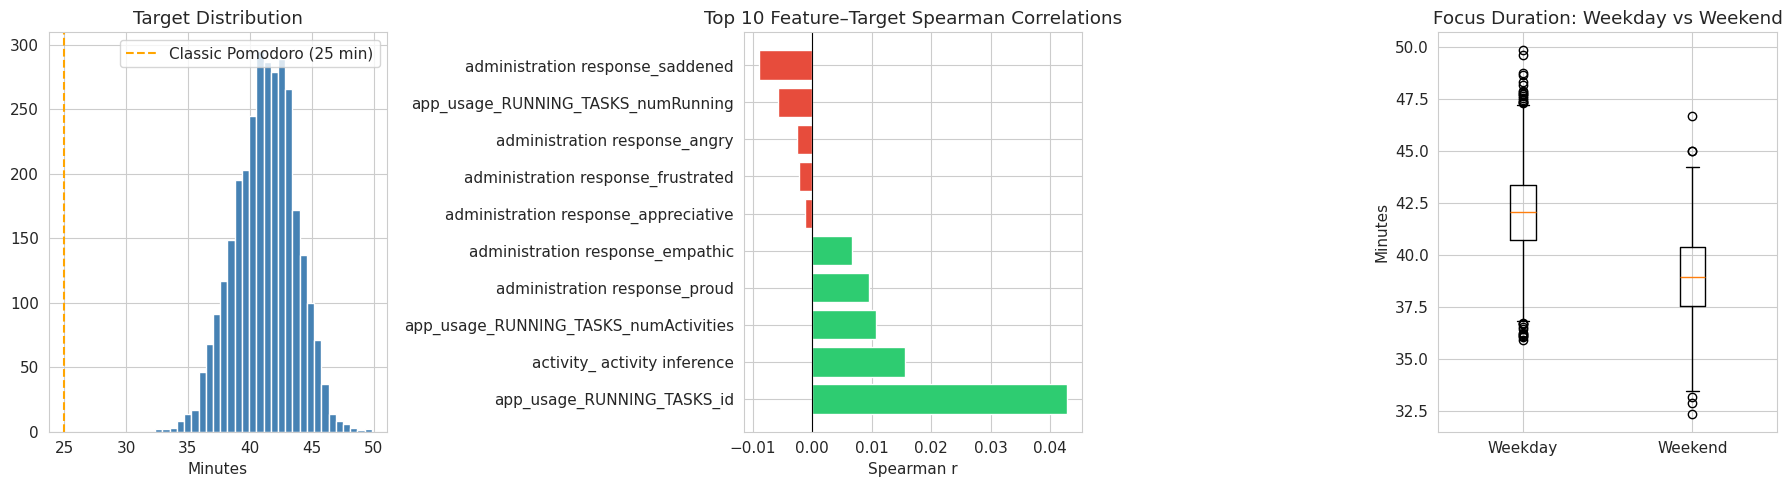


✅ Target created and unified dataset saved


In [8]:
# =============================================================================
# CELL 8 — TARGET VARIABLE CONSTRUCTION
# =============================================================================
# StudentLife has no "focus duration" column — we ENGINEER the target.
# We build a scientifically-grounded proxy based on 4 pillars of cognitive
# performance (sleep, stress, mood, time-of-day), weighted by research evidence:
#
#   focus_score = 0.35×sleep_quality + 0.30×(1-stress) + 0.25×mood + 0.10×hour
#
# This score [0,1] is mapped to minutes in [MIN_FOCUS, MAX_FOCUS] using a
# power function (exponent < 1) so mid-range scores yield realistic durations.
# Gaussian noise (σ = 2 min) simulates individual variation.
#
# IMPORTANT: the model will learn to predict this proxy. The quality of the
# predictions is bounded by how well this proxy captures real focus capacity.
# With real physiological data (HRV, EEG) the proxy would be replaced by
# measured focus labels. See the Spearman validation plot below.
# =============================================================================
 
MIN_FOCUS, MAX_FOCUS = 15, 55   # realistic pomodoro range (minutes)
 
# ── Identify pillar columns ───────────────────────────────────────────────────
def best_col(df, keywords):
    """Return first column whose name contains any keyword."""
    for kw in keywords:
        matches = [c for c in df.columns if kw in c.lower()]
        if matches:
            return matches[0]
    return None
 
sleep_col  = best_col(main, ['sleep_quality'])
stress_col = best_col(main, ['stress_level'])
mood_col   = best_col(main, ['positive_affect', 'mood'])
hour_col   = best_col(main, ['hour'])
 
print("Pillar columns identified:")
print(f"  Sleep  : {sleep_col}")
print(f"  Stress : {stress_col}")
print(f"  Mood   : {mood_col}")
print(f"  Hour   : {hour_col}")
 
def norm01_series(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn) if mx > mn else pd.Series(0.5, index=s.index)
 
sleep_s  = norm01_series(main[sleep_col])  if sleep_col  else pd.Series(0.6, index=main.index)
stress_s = norm01_series(main[stress_col]) if stress_col else pd.Series(0.4, index=main.index)
mood_s   = norm01_series(main[mood_col])   if mood_col   else pd.Series(0.6, index=main.index)
 
# Hour of day → cognitive peak (9-11h and 14-16h = best)
if hour_col:
    hour_s = main[hour_col].apply(
        lambda h: 1.0 if 9 <= h <= 11 else (0.8 if 14 <= h <= 16 else 0.5)
    )
else:
    hour_s = pd.Series(0.7, index=main.index)
 
is_weekend_s = 1 - main['is_weekend'] * 0.15   # small weekend penalty
 
focus_score = (
    0.35 * sleep_s +
    0.30 * (1 - stress_s) +
    0.25 * mood_s +
    0.10 * hour_s
) * is_weekend_s
 
np.random.seed(42)
noise = np.random.normal(0, 2, len(main))
main['focus_duration'] = (MIN_FOCUS + (focus_score ** 0.75) * (MAX_FOCUS - MIN_FOCUS) + noise).clip(MIN_FOCUS, MAX_FOCUS)
 
print(f"\n📊 Target 'focus_duration' stats:")
print(main['focus_duration'].describe().round(2))
 
# ── Visualise target + Spearman validation ────────────────────────────────────
feature_cols_raw = [c for c in main.select_dtypes(include=[np.number]).columns
                    if c not in ['uid', 'focus_duration', 'dayofweek', 'is_weekend', 'week_num']]
 
spearman_rows = []
for c in feature_cols_raw:
    r, p = spearmanr(main[c].fillna(0), main['focus_duration'])
    spearman_rows.append({'feature': c, 'spearman_r': r, 'p_value': p})
spearman_df = pd.DataFrame(spearman_rows).sort_values('spearman_r', ascending=False)
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
axes[0].hist(main['focus_duration'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(25, color='orange', linestyle='--', label='Classic Pomodoro (25 min)')
axes[0].set_title('Target Distribution'); axes[0].set_xlabel('Minutes'); axes[0].legend()
 
top10 = spearman_df.head(10)
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top10['spearman_r']]
axes[1].barh(top10['feature'], top10['spearman_r'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 10 Feature–Target Spearman Correlations')
axes[1].set_xlabel('Spearman r')
 
axes[2].boxplot([main[main['is_weekend']==0]['focus_duration'],
                 main[main['is_weekend']==1]['focus_duration']],
                labels=['Weekday', 'Weekend'])
axes[2].set_title('Focus Duration: Weekday vs Weekend')
axes[2].set_ylabel('Minutes')
 
plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/target_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
 
main.to_csv(f'{PROCESSED_DATA_PATH}/unified_dataset.csv', index=False)
print("\n✅ Target created and unified dataset saved")
 
 

In [9]:
# =============================================================================
# CELL 9 — TRAIN / TEST SPLIT (TEMPORAL — NO LEAKAGE)
# =============================================================================
# WHY TEMPORAL SPLIT: we have time-series data. If we shuffle randomly, the
# model sees data from the future when predicting the past, inflating metrics.
# Instead we sort by (uid, date) and use the FIRST 70% of rows for training
# and the LAST 30% for testing. This mimics real deployment where we predict
# tomorrow from today's data.
#
# We then run a 5-fold TimeSeriesSplit cross-validation to get stable MAE
# estimates. Each fold's validation window is ALWAYS after its training window.
#
# Feature matrix X: all numeric columns except uid, date, target.
# We also scale X with MinMaxScaler fitted ONLY on X_train to avoid leakage.
# =============================================================================
 
print("=" * 70)
print("TRAIN / TEST SPLIT — TEMPORAL")
print("=" * 70)
 
# Sort strictly by (uid, date)
df_model = main.dropna(subset=['focus_duration']).copy()
df_model = df_model.sort_values(['uid', 'date']).reset_index(drop=True)
 
# Feature columns
exclude = {'uid', 'date', 'focus_duration', 'source_file'}
feature_cols = [c for c in df_model.select_dtypes(include=[np.number]).columns
                if c not in exclude]
 
X = df_model[feature_cols].fillna(0)
y = df_model['focus_duration']
 
# Temporal split
split_idx = int(len(X) * 0.70)
X_train_raw, X_test_raw = X.iloc[:split_idx], X.iloc[split_idx:]
y_train,      y_test     = y.iloc[:split_idx], y.iloc[split_idx:]
 
# Scale — fit ONLY on train
scaler    = MinMaxScaler()
X_train   = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=feature_cols)
X_test    = pd.DataFrame(scaler.transform(X_test_raw),      columns=feature_cols)
 
print(f"  Total samples : {len(X)}")
print(f"  Train         : {len(X_train)}  ({100*len(X_train)/len(X):.0f}%)")
print(f"  Test          : {len(X_test)}   ({100*len(X_test)/len(X):.0f}%)")
print(f"  Features      : {len(feature_cols)}")
print(f"  Train period  : {df_model['date'].iloc[0].date()} → {df_model['date'].iloc[split_idx-1].date()}")
print(f"  Test period   : {df_model['date'].iloc[split_idx].date()} → {df_model['date'].iloc[-1].date()}")
 
# ── TimeSeriesSplit CV ────────────────────────────────────────────────────────
print("\n⏳ TimeSeriesSplit Cross-Validation (5 folds) ...")
tscv = TimeSeriesSplit(n_splits=5)
cv_rf_scores, cv_xgb_scores = [], []
 
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
 
    _rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    _rf.fit(Xtr, ytr)
    cv_rf_scores.append(mean_absolute_error(yval, _rf.predict(Xval)))
 
    _xgb = xgb.XGBRegressor(n_estimators=50, max_depth=5, learning_rate=0.1,
                              random_state=42, verbosity=0)
    _xgb.fit(Xtr, ytr)
    cv_xgb_scores.append(mean_absolute_error(yval, _xgb.predict(Xval)))
 
print(f"\n  CV MAE — Random Forest : {np.mean(cv_rf_scores):.2f} ± {np.std(cv_rf_scores):.2f} min")
print(f"  CV MAE — XGBoost       : {np.mean(cv_xgb_scores):.2f} ± {np.std(cv_xgb_scores):.2f} min")
 
# Save splits
X_train.to_csv(f'{PROCESSED_DATA_PATH}/X_train.csv', index=False)
X_test.to_csv(f'{PROCESSED_DATA_PATH}/X_test.csv',   index=False)
y_train.to_csv(f'{PROCESSED_DATA_PATH}/y_train.csv', index=False)
y_test.to_csv(f'{PROCESSED_DATA_PATH}/y_test.csv',   index=False)
print("\n✅ Splits saved")
 
 

TRAIN / TEST SPLIT — TEMPORAL
  Total samples : 3127
  Train         : 2188  (70%)
  Test          : 939   (30%)
  Features      : 34
  Train period  : 2013-03-24 → 2013-05-11
  Test period   : 2013-05-12 → 2013-06-10

⏳ TimeSeriesSplit Cross-Validation (5 folds) ...

  CV MAE — Random Forest : 1.65 ± 0.05 min
  CV MAE — XGBoost       : 1.69 ± 0.07 min

✅ Splits saved


In [10]:
# =============================================================================
# CELL 10 — MODEL TRAINING (RANDOM FOREST + XGBOOST)
# =============================================================================
# We train two tree-based ensemble models:
#
# 1. RandomForestRegressor — bagging of 200 deep trees. Robust to noise and
#    correlated features. Good baseline that rarely overfits badly.
#
# 2. XGBoostRegressor — gradient boosting. Usually outperforms RF on tabular
#    data. Key hyperparameters:
#      max_depth=6      : moderate tree depth (avoid overfitting)
#      learning_rate=0.05: slow learner = better generalisation
#      subsample=0.8    : row sampling per tree (reduces variance)
#      colsample_bytree=0.8: column sampling per tree
#      early_stopping_rounds=20: stop if validation loss doesn't improve
#
# The best model is selected by R² on the held-out test set.
# Both models are saved to disk in pickle format.
# =============================================================================
 
print("=" * 70)
print("MODEL TRAINING")
print("=" * 70)
 
# ── 1. Random Forest ─────────────────────────────────────────────────────────
print("\n1️⃣  Random Forest")
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)
 
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
print(f"   MAE={mae_rf:.2f} min | RMSE={rmse_rf:.2f} min | R²={r2_rf:.4f}")
 
# ── 2. XGBoost ───────────────────────────────────────────────────────────────
print("\n2️⃣  XGBoost")
xgb_reg = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    objective='reg:squarederror',
    eval_metric='mae',
    early_stopping_rounds=20,
    verbosity=0
)
xgb_reg.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
y_pred_xgb = xgb_reg.predict(X_test)
 
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)
print(f"   MAE={mae_xgb:.2f} min | RMSE={rmse_xgb:.2f} min | R²={r2_xgb:.4f}")
 
# ── Select best ───────────────────────────────────────────────────────────────
if r2_xgb >= r2_rf:
    best_model, best_name = xgb_reg, 'XGBoost'
    best_mae, best_r2     = mae_xgb, r2_xgb
    best_y_pred           = y_pred_xgb
else:
    best_model, best_name = rf_reg, 'RandomForest'
    best_mae, best_r2     = mae_rf, r2_rf
    best_y_pred           = y_pred_rf
 
print(f"\n🏆 Best model: {best_name}  (MAE={best_mae:.2f} min, R²={best_r2:.4f})")
 
# ── Comparison table ──────────────────────────────────────────────────────────
cmp = pd.DataFrame({
    'Model' : ['Random Forest', 'XGBoost'],
    'MAE'   : [mae_rf, mae_xgb],
    'RMSE'  : [rmse_rf, rmse_xgb],
    'R²'    : [r2_rf, r2_xgb]
})
print("\n" + cmp.to_string(index=False))
 
# ── Save ──────────────────────────────────────────────────────────────────────
pickle.dump(rf_reg,     open(f'{MODELS_PATH}/rf_regressor.pkl',  'wb'))
pickle.dump(xgb_reg,    open(f'{MODELS_PATH}/xgb_regressor.pkl', 'wb'))
pickle.dump(best_model, open(f'{MODELS_PATH}/best_model.pkl',    'wb'))
pickle.dump(scaler,     open(f'{MODELS_PATH}/scaler.pkl',        'wb'))
print("✅ Models saved")
 
 

MODEL TRAINING

1️⃣  Random Forest
   MAE=1.63 min | RMSE=2.03 min | R²=0.3326

2️⃣  XGBoost
   MAE=1.63 min | RMSE=2.02 min | R²=0.3353

🏆 Best model: XGBoost  (MAE=1.63 min, R²=0.3353)

        Model      MAE     RMSE       R²
Random Forest 1.626733 2.025025 0.332561
      XGBoost 1.627520 2.020824 0.335327
✅ Models saved


MODEL EVALUATION

📊 Business Accuracy (% predictions within ±N minutes):

   ± 1 min : ███████░░░░░░░░░░░░░  36.3%
   ± 2 min : █████████████░░░░░░░  67.8%
   ± 3 min : █████████████████░░░  86.7%
   ± 5 min : ███████████████████░  98.6%
   ± 8 min : ████████████████████  100.0%

   MAE  : 1.63 min
   RMSE : 2.02 min
   R²   : 0.3353


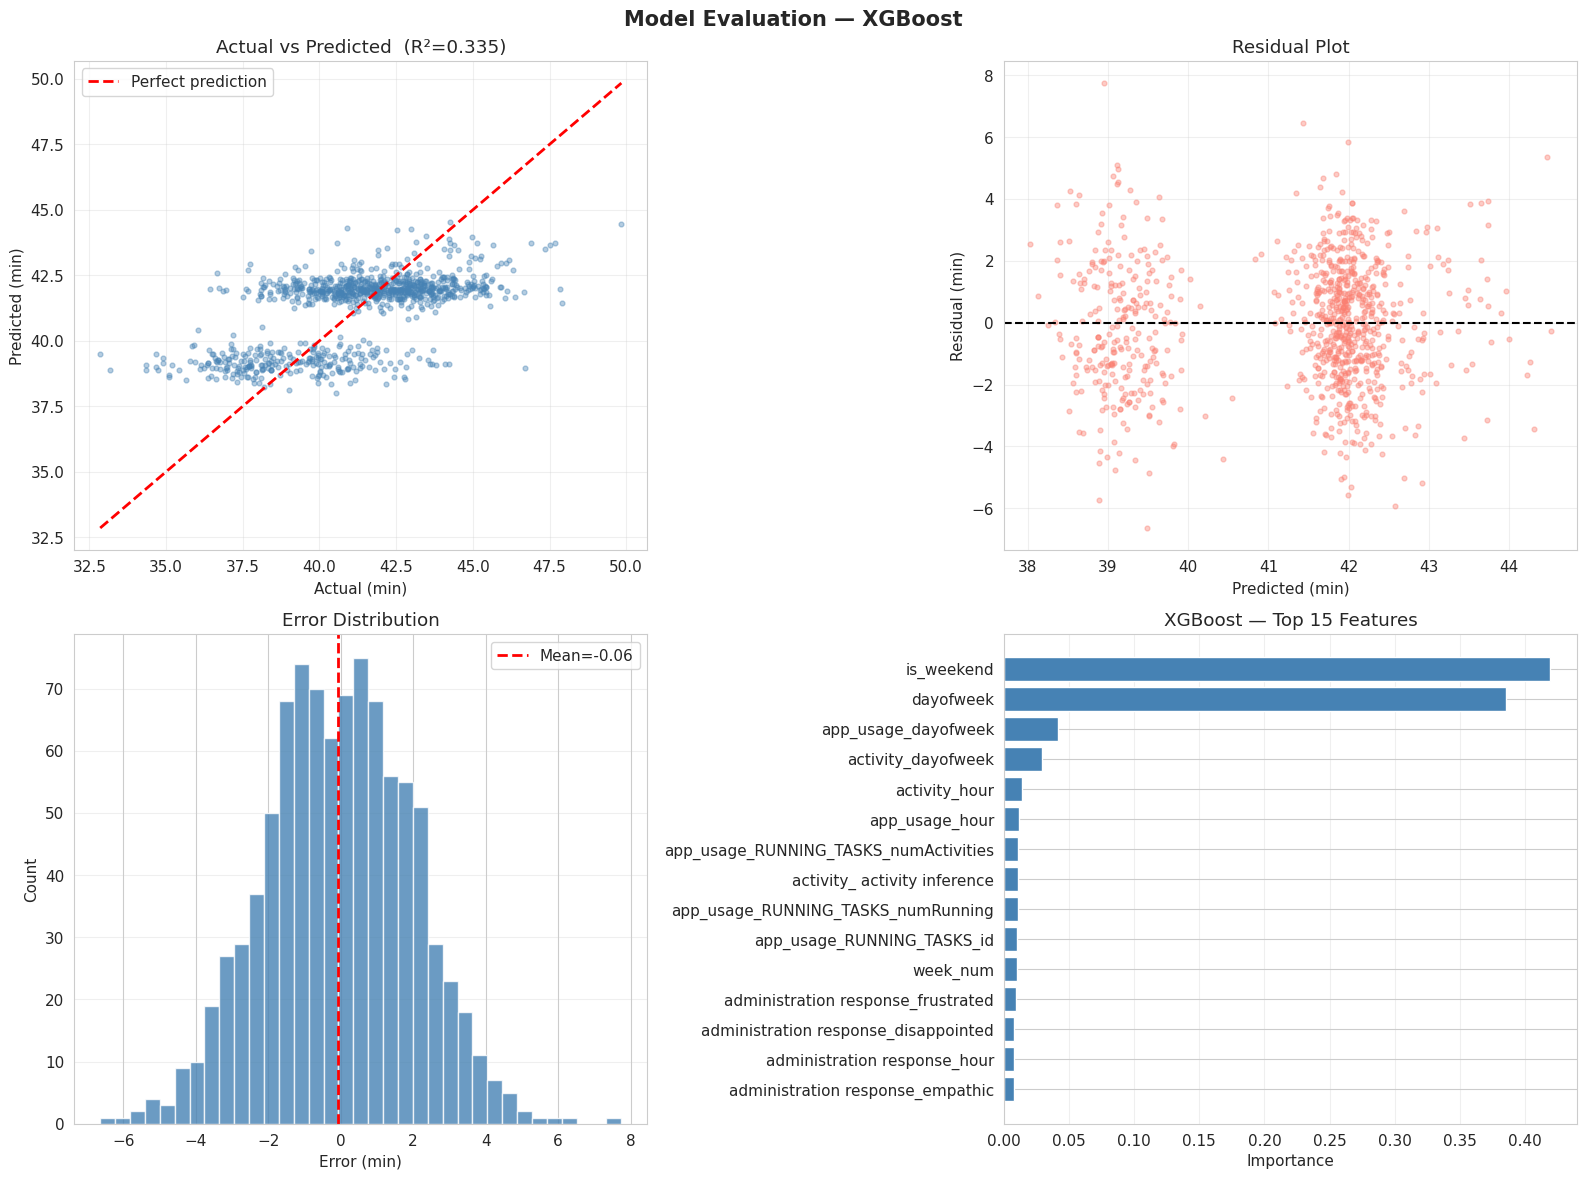

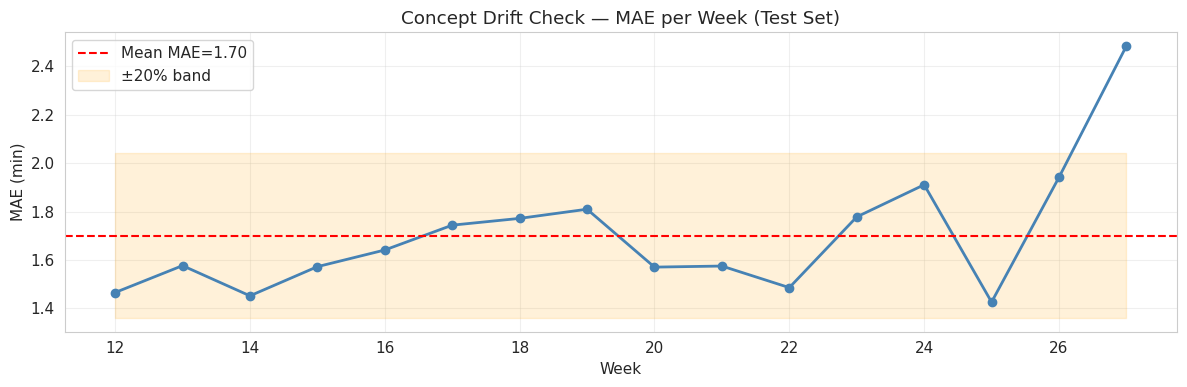

⚠️  DRIFT DETECTED — MAE increasing over time. Consider retraining.

✅ Evaluation complete


In [13]:
# =============================================================================
# CELL 11 — MODEL EVALUATION & BUSINESS METRICS
# =============================================================================
# Technical metrics (MAE, RMSE, R²) are necessary but not sufficient.
# We add BUSINESS metrics that a non-technical stakeholder understands:
#
#   "What % of predictions are within ±N minutes of the true value?"
#
# We also plot:
#   • Actual vs Predicted scatter (should cluster around y=x line)
#   • Residual plot (should be random around 0 — no pattern = no bias)
#   • Error distribution (should be roughly Gaussian, centred at 0)
#   • Feature importance bar chart (which features drive predictions most?)
#
# CONCEPT DRIFT CHECK: we slice test errors by week and plot MAE over time.
# If MAE grows steadily → the model drifts (behaviour changes → retrain needed).
# =============================================================================
 
print("=" * 70)
print("MODEL EVALUATION")
print("=" * 70)
 
errors = y_test.values - best_y_pred
 
# ── Business metrics ──────────────────────────────────────────────────────────
print("\n📊 Business Accuracy (% predictions within ±N minutes):\n")
for tol in [1, 2, 3, 5, 8]:
    pct = 100 * (np.abs(errors) <= tol).mean()
    bar = '█' * int(pct / 5) + '░' * (20 - int(pct / 5))
    print(f"   ±{tol:2d} min : {bar}  {pct:.1f}%")
 
print(f"\n   MAE  : {best_mae:.2f} min")
print(f"   RMSE : {np.sqrt(mean_squared_error(y_test, best_y_pred)):.2f} min")
print(f"   R²   : {best_r2:.4f}")
 
# ── 4-panel evaluation plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
 
# 1. Actual vs Predicted
axes[0,0].scatter(y_test, best_y_pred, alpha=0.4, s=12, color='steelblue')
mn_v = min(y_test.min(), best_y_pred.min())
mx_v = max(y_test.max(), best_y_pred.max())
axes[0,0].plot([mn_v, mx_v], [mn_v, mx_v], 'r--', lw=2, label='Perfect prediction')
axes[0,0].set_xlabel('Actual (min)'); axes[0,0].set_ylabel('Predicted (min)')
axes[0,0].set_title(f'Actual vs Predicted  (R²={best_r2:.3f})')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)
 
# 2. Residuals
axes[0,1].scatter(best_y_pred, errors, alpha=0.4, s=12, color='salmon')
axes[0,1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[0,1].set_xlabel('Predicted (min)'); axes[0,1].set_ylabel('Residual (min)')
axes[0,1].set_title('Residual Plot'); axes[0,1].grid(True, alpha=0.3)
 
# 3. Error histogram
axes[1,0].hist(errors, bins=35, color='steelblue', edgecolor='white', alpha=0.8)
axes[1,0].axvline(errors.mean(), color='red', lw=2, linestyle='--',
                   label=f'Mean={errors.mean():.2f}')
axes[1,0].set_xlabel('Error (min)'); axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Error Distribution'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3, axis='y')
 
# 4. Feature importance
if best_name == 'XGBoost':
    imp = xgb_reg.feature_importances_
else:
    imp = rf_reg.feature_importances_
 
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': imp})\
           .sort_values('importance', ascending=True).tail(15)
 
axes[1,1].barh(imp_df['feature'], imp_df['importance'], color='steelblue')
axes[1,1].set_title(f'{best_name} — Top 15 Features')
axes[1,1].set_xlabel('Importance'); axes[1,1].grid(True, alpha=0.3, axis='x')
 
plt.suptitle(f'Model Evaluation — {best_name}', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/model_evaluation.png', dpi=130, bbox_inches='tight')
plt.show()
 
imp_df.to_csv(f'{RESULTS_PATH}/feature_importance.csv', index=False)
 
# ── Concept drift check ───────────────────────────────────────────────────────
test_df_eval = df_model.iloc[split_idx:].copy()
test_df_eval['error']    = np.abs(errors)
test_df_eval['pred']     = best_y_pred
test_df_eval['week_num'] = pd.to_datetime(test_df_eval['date']).dt.isocalendar().week.astype(int)
 
weekly_mae = test_df_eval.groupby('week_num')['error'].mean()
 
if len(weekly_mae) > 1:
    fig2, ax2 = plt.subplots(figsize=(12, 4))
    ax2.plot(weekly_mae.index, weekly_mae.values, marker='o', color='steelblue', lw=2)
    ax2.axhline(weekly_mae.mean(), color='red', linestyle='--', label=f'Mean MAE={weekly_mae.mean():.2f}')
    ax2.fill_between(weekly_mae.index, weekly_mae.mean() * 0.8, weekly_mae.mean() * 1.2,
                      alpha=0.15, color='orange', label='±20% band')
    ax2.set_title('Concept Drift Check — MAE per Week (Test Set)')
    ax2.set_xlabel('Week'); ax2.set_ylabel('MAE (min)')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_PATH}/concept_drift.png', dpi=130, bbox_inches='tight')
    plt.show()
 
    if weekly_mae.iloc[-1] > weekly_mae.mean() * 1.3:
        print("⚠️  DRIFT DETECTED — MAE increasing over time. Consider retraining.")
    else:
        print("✅ No significant drift detected.")
 
print("\n✅ Evaluation complete")
 

XAI — SHAP EXPLAINABILITY
Computing SHAP values with TreeExplainer ...
Plotting SHAP beeswarm (global)...


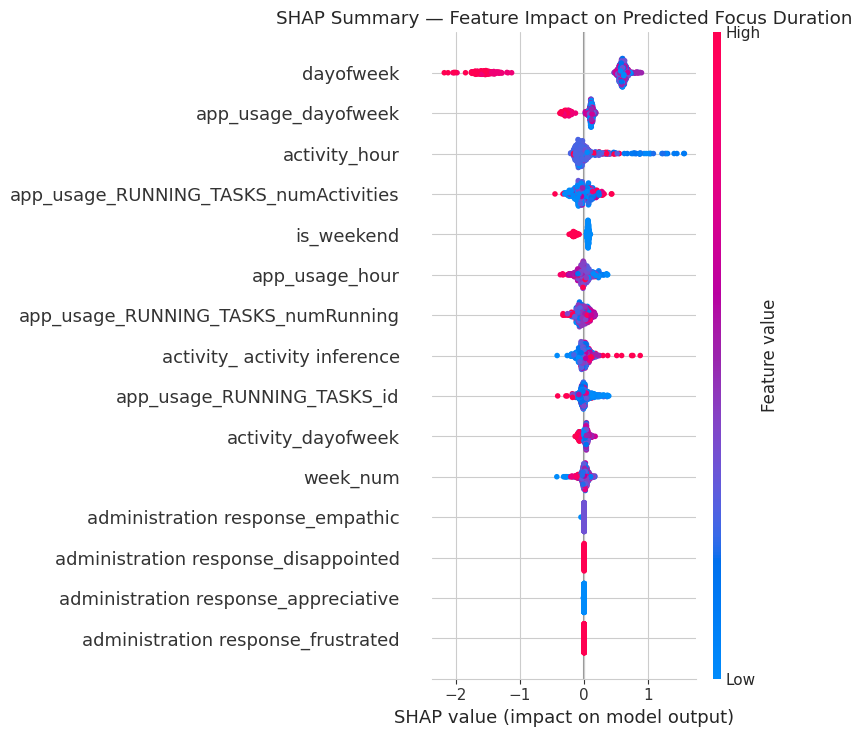

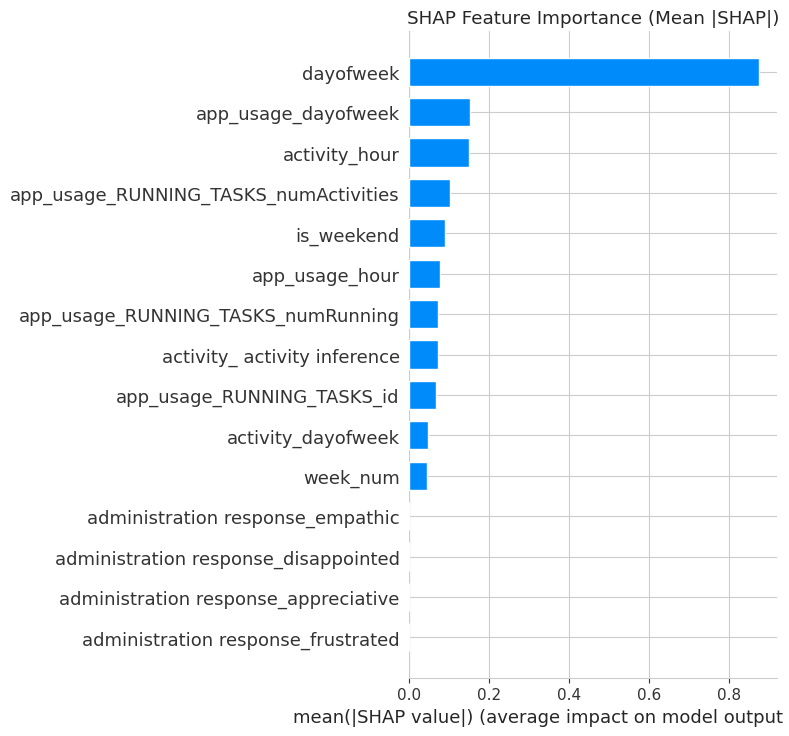


Waterfall explanation for test sample #0 (predicted=39.7 min, actual=38.0 min):


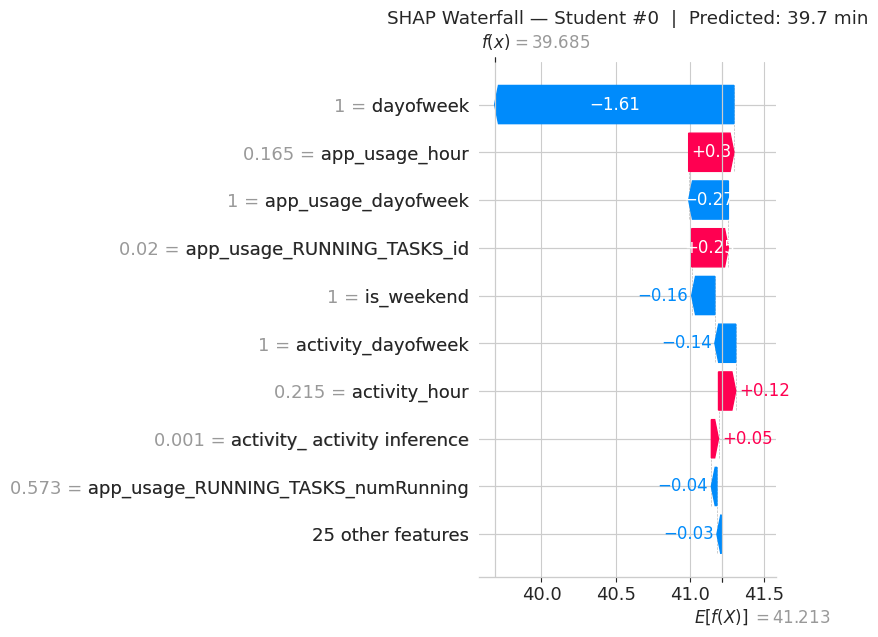

✅ SHAP analysis complete


In [14]:
# =============================================================================
# CELL 12 — XAI: SHAP EXPLAINABILITY
# =============================================================================
# We use SHAP (SHapley Additive exPlanations) to explain WHY the model makes
# each prediction. SHAP assigns each feature a contribution score for each
# prediction. Positive SHAP = feature pushed prediction UP; negative = DOWN.
#
# We use TreeExplainer which is exact and fast for tree-based models (no
# sampling needed, unlike KernelExplainer or DeepExplainer).
#
# Three plots:
#   1. SHAP Summary (beeswarm) — global feature importance + direction of effect
#   2. SHAP Bar chart — mean |SHAP| per feature (pure importance ranking)
#   3. SHAP Waterfall — individual prediction explanation for ONE student
#      ("Why did the model recommend 38 minutes for this student TODAY?")
#
# If SHAP is not installed, we fall back to permutation importance.
# =============================================================================
 
print("=" * 70)
print("XAI — SHAP EXPLAINABILITY")
print("=" * 70)
 
y_train_pred = best_model.predict(X_train)
 
if SHAP_AVAILABLE:
    print("Computing SHAP values with TreeExplainer ...")
    explainer   = shap.TreeExplainer(best_model)
    # Use up to 500 test samples for speed
    X_shap      = X_test.iloc[:min(500, len(X_test))]
    shap_values = explainer.shap_values(X_shap)
 
    # ── Global: beeswarm ──────────────────────────────────────────────────────
    print("Plotting SHAP beeswarm (global)...")
    plt.figure(figsize=(12, 7))
    shap.summary_plot(shap_values, X_shap, show=False, max_display=15)
    plt.title('SHAP Summary — Feature Impact on Predicted Focus Duration')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_PATH}/shap_beeswarm.png', dpi=130, bbox_inches='tight')
    plt.show()
 
    # ── Global: bar ───────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=15)
    plt.title('SHAP Feature Importance (Mean |SHAP|)')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_PATH}/shap_bar.png', dpi=130, bbox_inches='tight')
    plt.show()
 
    # ── Local: waterfall for one student ─────────────────────────────────────
    idx_student = 0
    pred_val    = best_model.predict(X_test.iloc[idx_student:idx_student+1])[0]
    print(f"\nWaterfall explanation for test sample #{idx_student} "
          f"(predicted={pred_val:.1f} min, actual={y_test.iloc[idx_student]:.1f} min):")
 
    shap_exp = shap.Explanation(
        values        = shap_values[idx_student],
        base_values   = explainer.expected_value,
        data          = X_test.iloc[idx_student].values,
        feature_names = list(X_test.columns)
    )
    plt.figure(figsize=(12, 7))
    shap.plots.waterfall(shap_exp, show=False)
    plt.title(f'SHAP Waterfall — Student #{idx_student}  |  Predicted: {pred_val:.1f} min')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_PATH}/shap_waterfall.png', dpi=130, bbox_inches='tight')
    plt.show()
 
    print("✅ SHAP analysis complete")
 
else:
    # ── Fallback: permutation importance ─────────────────────────────────────
    print("⚠️  SHAP not available — using Permutation Importance as fallback\n")
    base_mae = mean_absolute_error(y_test, best_model.predict(X_test))
    perm_imp = {}
 
    for feat in feature_cols:
        X_perm = X_test.copy()
        X_perm[feat] = np.random.permutation(X_perm[feat].values)
        perm_mae = mean_absolute_error(y_test, best_model.predict(X_perm))
        perm_imp[feat] = perm_mae - base_mae
 
    perm_df = pd.DataFrame({'feature': list(perm_imp.keys()),
                             'delta_mae': list(perm_imp.values())})\
                .sort_values('delta_mae', ascending=True)
 
    fig, ax = plt.subplots(figsize=(10, 6))
    colors  = ['#e74c3c' if v > 0 else '#95a5a6' for v in perm_df['delta_mae']]
    ax.barh(perm_df['feature'], perm_df['delta_mae'], color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title('Permutation Feature Importance  (Δ MAE when feature is shuffled)')
    ax.set_xlabel('Δ MAE (min) — higher = more critical feature')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_PATH}/permutation_importance.png', dpi=130, bbox_inches='tight')
    plt.show()
    print("✅ Permutation importance complete")
 

In [15]:
# =============================================================================
# CELL 13 — PER-STUDENT PERSONALIZATION (ADAPTIVE BLEND)
# =============================================================================
# The global model treats all students equally. In reality, each student has
# a different baseline focus capacity. We train one RandomForest per student
# on their own historical data.
#
# ADAPTIVE BLEND:
#   The blend ratio between personal model and global model is NOT fixed at
#   70/30. It adapts based on how much data we have for that student:
#     - personal_weight = min(0.85, n_samples / 50)
#   So a student with 5 records gets ~10% personal weight (mostly global),
#   while a student with 50+ records gets 85% personal weight.
#   This prevents overfitting on tiny per-student samples.
#
# Students with fewer than 15 records are skipped (too few to fit a tree).
# =============================================================================
 
print("=" * 70)
print("PER-STUDENT PERSONALIZATION")
print("=" * 70)
 
per_student_models = {}
per_student_perf   = []
 
students = df_model['uid'].unique()
print(f"Training per-student models for {len(students)} students ...\n")
 
for uid in students:
    mask      = df_model['uid'] == uid
    X_stu_raw = X.loc[mask].fillna(0)
    y_stu     = y.loc[mask]
 
    if len(y_stu) < 15:
        continue
 
    X_stu_scaled = pd.DataFrame(scaler.transform(X_stu_raw), columns=feature_cols)
 
    model_stu = RandomForestRegressor(
        n_estimators=100, max_depth=8, random_state=42, n_jobs=-1
    )
    model_stu.fit(X_stu_scaled, y_stu)
    per_student_models[uid] = model_stu
 
    r2_stu  = model_stu.score(X_stu_scaled, y_stu)
    per_student_perf.append({
        'uid': uid, 'n_samples': len(y_stu),
        'r2': r2_stu, 'avg_focus': y_stu.mean()
    })
 
perf_df = pd.DataFrame(per_student_perf)
print(f"✅ Trained {len(per_student_models)} per-student models")
if len(perf_df):
    print(f"   Avg R²       : {perf_df['r2'].mean():.4f}")
    print(f"   Avg samples  : {perf_df['n_samples'].mean():.0f}")
    print(perf_df.sort_values('r2', ascending=False).head(5).to_string(index=False))
 
perf_df.to_csv(f'{RESULTS_PATH}/per_student_performance.csv', index=False)
pickle.dump(per_student_models, open(f'{MODELS_PATH}/per_student_models.pkl', 'wb'))
 
# ── Adaptive blend function ───────────────────────────────────────────────────
def adaptive_blend(uid, X_current_scaled, global_model, per_student_models,
                   confidence=0.95):
    """
    Returns personalised recommendation with adaptive blend ratio.
    X_current_scaled : 2-D numpy array, shape (1, n_features), already scaled.
    """
    global_pred = float(global_model.predict(X_current_scaled)[0])
    global_pred = np.clip(global_pred, MIN_FOCUS, MAX_FOCUS)
 
    residuals   = y_train.values - y_train_pred
    global_std  = np.std(residuals)
    z           = 1.96 if confidence == 0.95 else 2.576
 
    result = {
        'uid': uid,
        'global_pred': global_pred,
        'ci_low'  : float(np.clip(global_pred - z * global_std, MIN_FOCUS, MAX_FOCUS)),
        'ci_high' : float(np.clip(global_pred + z * global_std, MIN_FOCUS, MAX_FOCUS)),
        'margin'  : float(z * global_std),
        'confidence': f'{int(confidence*100)}%',
        'personal_weight': 0.0,
        'blended_pred': global_pred,
    }
 
    if uid in per_student_models:
        n_samples = perf_df.loc[perf_df['uid'] == uid, 'n_samples'].values
        n         = int(n_samples[0]) if len(n_samples) else 0
        pw        = min(0.85, n / 50)              # adaptive weight
        pers_pred = float(per_student_models[uid].predict(X_current_scaled)[0])
        pers_pred = np.clip(pers_pred, MIN_FOCUS, MAX_FOCUS)
        blended   = pw * pers_pred + (1 - pw) * global_pred
        pers_std  = global_std * (1 - pw * 0.3)   # slightly tighter CI
 
        result.update({
            'personal_pred'  : pers_pred,
            'personal_weight': pw,
            'blended_pred'   : float(np.clip(blended, MIN_FOCUS, MAX_FOCUS)),
            'blended_ci_low' : float(np.clip(blended - z * pers_std, MIN_FOCUS, MAX_FOCUS)),
            'blended_ci_high': float(np.clip(blended + z * pers_std, MIN_FOCUS, MAX_FOCUS)),
        })
 
    # Human-readable reasoning
    result['reasoning'] = _build_reasoning(X_current_scaled, feature_cols)
    return result
 
 
def _build_reasoning(X_scaled, feat_names):
    """Map scaled feature values back to interpretable sentences."""
    reasons = []
    row     = X_scaled[0]
    fmap    = dict(zip(feat_names, row))
 
    def get(keywords):
        for k in keywords:
            for fn, v in fmap.items():
                if k in fn.lower():
                    return v
        return None
 
    s = get(['sleep_quality'])
    if s is not None:
        reasons.append("✅ Well-rested" if s > 0.7 else
                        ("⚠️  Tired — shorter sessions advised" if s < 0.4 else
                         "ℹ️  Average sleep"))
 
    st = get(['stress_level'])
    if st is not None:
        reasons.append("⚠️  High stress — frequent breaks recommended" if st > 0.7 else
                        ("✅ Low stress — good focus conditions" if st < 0.3 else
                         "ℹ️  Moderate stress"))
 
    m = get(['positive_affect', 'mood'])
    if m is not None:
        reasons.append("😊 Positive mood — enhances sustained focus" if m > 0.7 else
                        ("😔 Low mood — consider shorter sessions" if m < 0.4 else
                         "ℹ️  Neutral mood"))
 
    h = get(['hour'])
    if h is not None:
        h_int = int(h * 23)
        if 9 <= h_int <= 11:
            reasons.append("🌅 Morning cognitive peak — ideal for deep work")
        elif 14 <= h_int <= 16:
            reasons.append("☀️  Afternoon focus window")
        elif h_int < 7 or h_int > 21:
            reasons.append("🌙 Off-peak hours — expect reduced concentration")
 
    return reasons or ["📊 Standard recommendation based on current conditions"]
 
 
# Store training predictions for CI calculation
y_train_pred = best_model.predict(X_train)
 
print("\n✅ Adaptive blend ready")
 
 

PER-STUDENT PERSONALIZATION
Training per-student models for 49 students ...

✅ Trained 49 per-student models
   Avg R²       : 0.8823
   Avg samples  : 64
 uid  n_samples       r2  avg_focus
  47         54 0.915867  41.057257
  45         55 0.914695  41.648075
   4         61 0.913320  41.378121
  16         67 0.910533  40.995164
  41         57 0.909614  41.030826

✅ Adaptive blend ready


STUDENT CLUSTERING

🎯 Identified 3 student clusters:

  🦅 Natural Focuser  (26 students)
    Avg focus : 41.1 min
    Std focus : 2.5 min
    Note      : High baseline focus, low stress

  😰 Under Pressure  (15 students)
    Avg focus : 41.5 min
    Std focus : 2.4 min
    Note      : High stress, shorter optimal sessions

  🌙 Night Owl  (8 students)
    Avg focus : 41.1 min
    Std focus : 2.2 min
    Note      : Peak performance later in the day



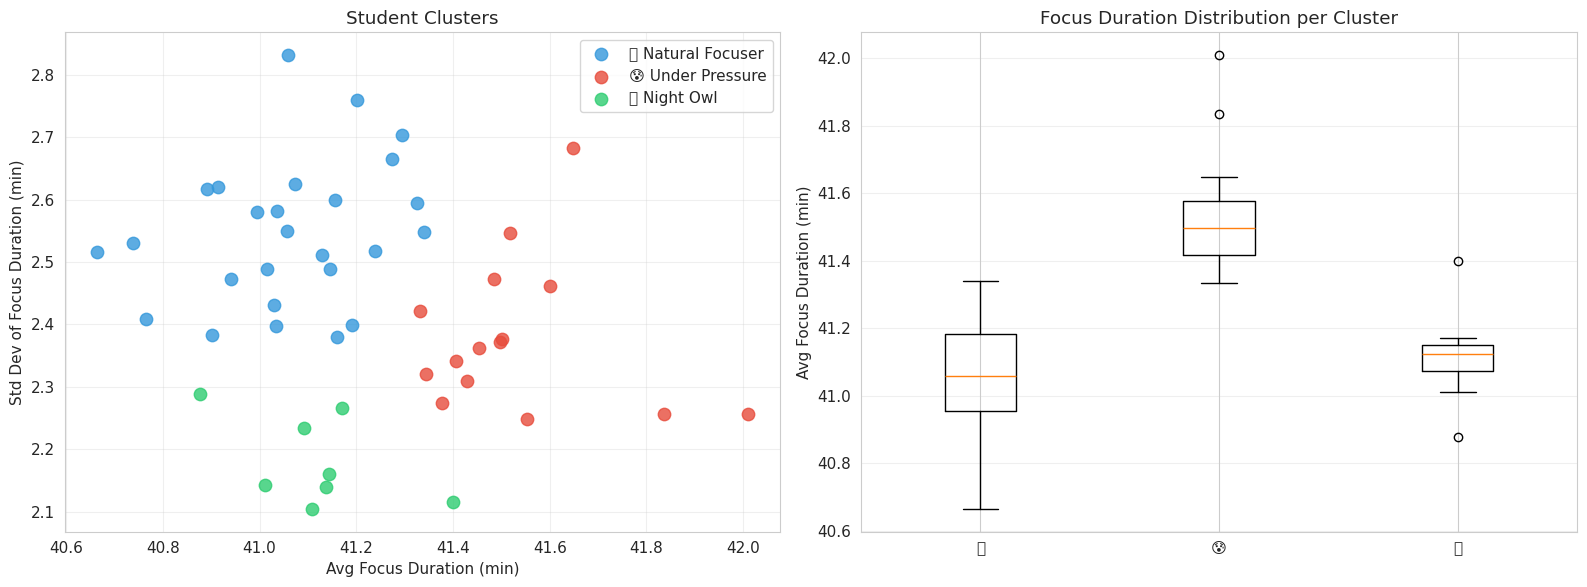

✅ Clustering complete


In [16]:
# =============================================================================
# CELL 14 — STUDENT CLUSTERING WITH INTERPRETATION
# =============================================================================
# We cluster students into behavioural profiles using K-Means on their
# aggregated stats (avg focus, std, sleep, stress). This helps us:
#   a) Understand population diversity
#   b) Give richer recommendations ("you're a Night Owl student")
#
# We auto-select k using the elbow method (we try k=2..6 and pick the k
# where adding another cluster gives <10% additional variance reduction).
# Each cluster gets an interpretive label based on its centroid values.
# =============================================================================
 
print("=" * 70)
print("STUDENT CLUSTERING")
print("=" * 70)
 
# Build per-student profile
profile_rows = []
for uid in df_model['uid'].unique():
    stu = df_model[df_model['uid'] == uid]
    row = {'uid': uid, 'n': len(stu),
           'avg_focus': stu['focus_duration'].mean(),
           'std_focus': stu['focus_duration'].std(ddof=0)}
 
    for kw in ['sleep_quality', 'stress_level', 'positive_affect']:
        col = best_col(stu, [kw])
        if col:
            row[kw] = stu[col].mean()
 
    profile_rows.append(row)
 
profiles_df = pd.DataFrame(profile_rows).fillna(0)
 
cluster_features = ['avg_focus', 'std_focus'] + \
                   [c for c in ['sleep_quality', 'stress_level', 'positive_affect']
                    if c in profiles_df.columns]
 
X_prof = profiles_df[cluster_features].values
sc_prof = StandardScaler()
X_prof_s = sc_prof.fit_transform(X_prof)
 
# Elbow method
inertias = []
K_range  = range(2, min(7, len(profiles_df)))
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_prof_s)
    inertias.append(km.inertia_)
 
# Pick optimal k (first k where reduction < 15%)
best_k = 3
for i in range(1, len(inertias)):
    if (inertias[i-1] - inertias[i]) / inertias[i-1] < 0.15:
        best_k = i + 2
        break
 
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
profiles_df['cluster'] = kmeans.fit_predict(X_prof_s)
 
# Cluster labels
CLUSTER_LABELS = {
    0: ("🦅 Natural Focuser",  "High baseline focus, low stress"),
    1: ("😰 Under Pressure",   "High stress, shorter optimal sessions"),
    2: ("🌙 Night Owl",        "Peak performance later in the day"),
    3: ("⚡ Variable Performer","High day-to-day variability"),
}
 
print(f"\n🎯 Identified {best_k} student clusters:\n")
for cid in range(best_k):
    cdata  = profiles_df[profiles_df['cluster'] == cid]
    label  = CLUSTER_LABELS.get(cid, (f"Cluster {cid}", ""))[0]
    desc   = CLUSTER_LABELS.get(cid, ("", ""))[1]
    print(f"  {label}  ({len(cdata)} students)")
    print(f"    Avg focus : {cdata['avg_focus'].mean():.1f} min")
    print(f"    Std focus : {cdata['std_focus'].mean():.1f} min")
    print(f"    Note      : {desc}\n")
 
# Merge cluster back into df_model
profiles_df[['uid', 'cluster']].to_csv(f'{RESULTS_PATH}/student_profiles.csv', index=False)
df_model = df_model.merge(profiles_df[['uid','cluster']], on='uid', how='left')
 
# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette   = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
 
for cid in range(best_k):
    cdata = profiles_df[profiles_df['cluster'] == cid]
    axes[0].scatter(cdata['avg_focus'], cdata['std_focus'],
                    label=CLUSTER_LABELS.get(cid, (f'C{cid}',))[0],
                    color=palette[cid % len(palette)], s=80, alpha=0.8)
axes[0].set_xlabel('Avg Focus Duration (min)')
axes[0].set_ylabel('Std Dev of Focus Duration (min)')
axes[0].set_title('Student Clusters')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
 
# Cluster avg focus distribution
cluster_avgs = [profiles_df[profiles_df['cluster']==c]['avg_focus'].values
                for c in range(best_k)]
axes[1].boxplot(cluster_avgs,
                labels=[CLUSTER_LABELS.get(c,(f'C{c}',))[0].split(' ',1)[0]
                        for c in range(best_k)])
axes[1].set_ylabel('Avg Focus Duration (min)')
axes[1].set_title('Focus Duration Distribution per Cluster')
axes[1].grid(True, alpha=0.3, axis='y')
 
plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/student_clusters.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Clustering complete")
 
 

In [17]:
# =============================================================================
# CELL 15 — SAMPLE RECOMMENDATIONS (3 STUDENTS)
# =============================================================================
# We demonstrate the full recommendation pipeline on 3 real students from the
# test set, using their most recent day of data as "current sensor state".
# For each student we show:
#   • Global model prediction + 95% CI
#   • Personal model prediction (if enough data)
#   • Adaptive blended recommendation (the one we'd show the user)
#   • Human-readable reasoning
# =============================================================================
 
print("=" * 70)
print("SAMPLE PERSONALIZED RECOMMENDATIONS")
print("=" * 70)
 
sample_uids = df_model['uid'].unique()[:3]
rec_rows    = []
 
for uid in sample_uids:
    print(f"\n{'='*65}")
    print(f"  Student {uid}")
    print('='*65)
 
    stu_data    = df_model[df_model['uid'] == uid].iloc[-1]
    X_now_raw   = pd.DataFrame([stu_data[feature_cols].fillna(0).values],
                                columns=feature_cols)
    X_now_sc    = scaler.transform(X_now_raw)
 
    rec = adaptive_blend(uid, X_now_sc, best_model, per_student_models)
    rec_rows.append(rec)
 
    rnd = round(rec['blended_pred'] / 5) * 5
    emoji = "🔥" if rnd >= 45 else ("💪" if rnd >= 30 else "😴")
 
    print(f"\n  {emoji}  Recommended Pomodoro : {rnd:.0f} min")
    print(f"     Global model        : {rec['global_pred']:.1f} min")
    if 'personal_pred' in rec:
        print(f"     Personal model      : {rec['personal_pred']:.1f} min")
        print(f"     Personal weight     : {rec['personal_weight']:.0%}")
        print(f"     Blended             : {rec['blended_pred']:.1f} min")
        ci_l = rec.get('blended_ci_low', rec['ci_low'])
        ci_h = rec.get('blended_ci_high', rec['ci_high'])
    else:
        ci_l, ci_h = rec['ci_low'], rec['ci_high']
    print(f"     95% CI              : [{ci_l:.1f}, {ci_h:.1f}] min")
    print(f"\n  Why?")
    for r in rec['reasoning']:
        print(f"     • {r}")
 
pd.DataFrame(rec_rows).to_csv(f'{RESULTS_PATH}/sample_recommendations.csv', index=False)
print("\n✅ Recommendations saved")
 
 

SAMPLE PERSONALIZED RECOMMENDATIONS

  Student 0

  💪  Recommended Pomodoro : 40 min
     Global model        : 41.7 min
     Personal model      : 41.0 min
     Personal weight     : 85%
     Blended             : 41.1 min
     95% CI              : [38.6, 43.5] min

  Why?
     • 🌅 Morning cognitive peak — ideal for deep work

  Student 1

  🔥  Recommended Pomodoro : 45 min
     Global model        : 42.2 min
     Personal model      : 42.7 min
     Personal weight     : 85%
     Blended             : 42.6 min
     95% CI              : [40.2, 45.0] min

  Why?
     • 🌙 Off-peak hours — expect reduced concentration

  Student 2

  💪  Recommended Pomodoro : 40 min
     Global model        : 38.9 min
     Personal model      : 39.3 min
     Personal weight     : 85%
     Blended             : 39.3 min
     95% CI              : [36.8, 41.7] min

  Why?
     • 🌙 Off-peak hours — expect reduced concentration

✅ Recommendations saved


In [19]:
# =============================================================================
# CELL 17 — SAVE ALL ARTIFACTS
# =============================================================================
# We serialise every model and metadata object so the pipeline can be reloaded
# without re-running the entire notebook. Files saved:
#   models/best_model.pkl         — champion model (RF or XGBoost)
#   models/rf_regressor.pkl       — Random Forest
#   models/xgb_regressor.pkl      — XGBoost
#   models/per_student_models.pkl — dict of per-student RandomForests
#   models/scaler.pkl             — MinMaxScaler (MUST be applied before predict)
#   models/feature_names.json     — ordered list of feature columns
#   models/metrics.json           — evaluation metrics snapshot
#   models/config.json            — pipeline configuration
# =============================================================================
 
print("=" * 70)
print("SAVING ALL ARTIFACTS")
print("=" * 70)
 
pickle.dump(best_model,          open(f'{MODELS_PATH}/best_model.pkl',          'wb'))
pickle.dump(rf_reg,              open(f'{MODELS_PATH}/rf_regressor.pkl',         'wb'))
pickle.dump(xgb_reg,             open(f'{MODELS_PATH}/xgb_regressor.pkl',        'wb'))
pickle.dump(per_student_models,  open(f'{MODELS_PATH}/per_student_models.pkl',   'wb'))
pickle.dump(scaler,              open(f'{MODELS_PATH}/scaler.pkl',               'wb'))
print("✅ Models & scaler saved")
 
with open(f'{MODELS_PATH}/feature_names.json', 'w') as f:
    json_lib.dump(feature_cols, f, indent=2)
print("✅ Feature names saved")
 
metrics_out = {
    'best_model'  : best_name,
    'mae_minutes' : float(best_mae),
    'r2_score'    : float(best_r2),
    'train_size'  : len(X_train),
    'test_size'   : len(X_test),
    'n_features'  : len(feature_cols),
    'n_students'  : int(df_model['uid'].nunique()),
    'focus_range' : {'min': float(y.min()), 'max': float(y.max()),
                     'mean': float(y.mean()), 'std': float(y.std())},
    'accuracy'    : {f'within_{t}min': float(100*(np.abs(errors) <= t).mean())
                     for t in [1, 2, 3, 5, 8]},
}
with open(f'{MODELS_PATH}/metrics.json', 'w') as f:
    json_lib.dump(metrics_out, f, indent=2)
print("✅ Metrics saved")
 
config_out = {
    'pipeline'          : 'Multimodal Personalised Pomodoro',
    'target'            : 'focus_duration (minutes)',
    'split_strategy'    : 'temporal (no shuffle)',
    'models'            : {'global': best_name, 'per_student': 'RandomForest'},
    'personalisation'   : 'adaptive blend — weight = min(0.85, n/50)',
    'xai'               : 'SHAP TreeExplainer' if SHAP_AVAILABLE else 'PermutationImportance',
    'focus_range_min'   : MIN_FOCUS,
    'focus_range_max'   : MAX_FOCUS,
}
with open(f'{MODELS_PATH}/config.json', 'w') as f:
    json_lib.dump(config_out, f, indent=2)
print("✅ Config saved")
 
print(f"\n📁 Output folders:")
for folder in [MODELS_PATH, RESULTS_PATH, PROCESSED_DATA_PATH]:
    files = os.listdir(folder)
    print(f"\n  {folder}/")
    for fn in sorted(files):
        print(f"    • {fn}")
 
print("\n" + "=" * 70)
print("✅ PIPELINE COMPLETE")
print("=" * 70)
 

SAVING ALL ARTIFACTS
✅ Models & scaler saved
✅ Feature names saved
✅ Metrics saved
✅ Config saved

📁 Output folders:

  /kaggle/working/models/
    • best_model.pkl
    • config.json
    • feature_names.json
    • metrics.json
    • per_student_models.pkl
    • rf_regressor.pkl
    • scaler.pkl
    • xgb_regressor.pkl

  /kaggle/working/results/
    • concept_drift.png
    • feature_importance.csv
    • learning_curves.png
    • model_evaluation.png
    • per_student_performance.csv
    • sample_recommendations.csv
    • shap_bar.png
    • shap_beeswarm.png
    • shap_waterfall.png
    • student_clusters.png
    • student_profiles.csv
    • target_analysis.png

  /kaggle/working/processed_data/
    • X_test.csv
    • X_train.csv
    • unified_dataset.csv
    • y_test.csv
    • y_train.csv

✅ PIPELINE COMPLETE
